In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import muon as mu
import scanpy as sc


mpl.rcParams.update({
    # --- Fonts: keep text editable ---
    'pdf.fonttype': 'truetype',   # same as 42, ensures TrueType fonts
    'ps.fonttype': 'truetype',    # for EPS compatibility
    'svg.fonttype': 'none',       # keeps SVG text as text, not outlines

    # --- PDF structure: keep elements separate ---
    'pdf.compression': 0,         # prevents grouping/merging of vector paths
    'savefig.transparent': True,  # optional: preserves transparent backgrounds
    'savefig.bbox': 'tight',      # trims whitespace
    'savefig.pad_inches': 0.02,   # small padding for Illustrator bleed safety

    # --- General style niceties ---
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.family': 'sans-serif'
})

from IPython.display import display, HTML
display(HTML("<style>.jp-Cell { margin-left: -20% !important; margin-right: -15% !important; }</style>"))

In [2]:
#colors
colors_sheet = pd.read_excel('../data/production_color_v1.xlsx') #test sheet

#make leiden cluster color dictionary
colors_dict = dict(zip(colors_sheet.leiden, colors_sheet.colour))

In [3]:
# Read in CITEseq data
mdata = mu.read_h5ad('../Data/GEO_data_file_v1.h5mu', mod = 'protein')
mdata.var_names_make_unique()
mdata

AnnData object with n_obs × n_vars = 33853 × 272
    obs: 'capture_pool', 'patient_alias', 'time', 'leiden'
    layers: 'counts'

In [4]:
#Create and export master data
df_all = pd.DataFrame(mdata.layers['counts'].A, columns = mdata.var_names,  index=mdata.obs_names)
df_all["leiden"] = mdata.obs["leiden"].astype(int).values
df_all["patient_alias"] = mdata.obs["patient_alias"].values
df_all['timepoint'] = mdata.obs['time'].values

In [9]:
#Trying out using an excel sheet to compile config for the CITEseq plots
#Get sheet names
#xls = pd.ExcelFile('../Data/Copy of citeseq_gating_params.xlsx')
xls = pd.ExcelFile('../Data/citeseq_gating_params_v2.xlsx') #updated parameters from Liv
sheets = xls.sheet_names
sheets

['P18', 'P17', 'P03']

In [11]:
#Order of plots (x1, y1, x2, y2, x3, y3)
plot_order = {}
plot_order['P18'] = dict(zip([0,1,2,3,4,5], ['ADT.CD45RA', 'ADT.CD7', 'ADT.CD56', 'ADT.CD36', 'ADT.CD40', 'ADT.CD36']))
plot_order['P17'] = dict(zip([0,1,2,3,4,5], ['ADT.CD31', 'ADT.CD49b', 'ADT.GPR56', 'ADT.CD34', 'ADT.CD71', 'ADT.CD34']))
plot_order['P03'] = dict(zip([0,1,2,3,4,5], ['ADT.CD45RA', 'ADT.CD34', 'ADT.CD49b', 'ADT.GPR56', 'ADT.CD71', 'ADT.GPR56']))

In [13]:
#Make a big gate dictionary here
gate_dict = {'P18':{'ADT.CD45RA': 150,
                 'ADT.CD7': 10,
                 'ADT.CD36': 30,
                 'ADT.CD56': 100,
                 'ADT.CD40': 20},
            'P17': {'ADT.CD34': 300, 
                 'ADT.GPR56':50, 
                 'ADT.CD49b':40, 
                 'ADT.CD71':200,
                 'ADT.CD31':800},
            'P03': {'ADT.CD34': 80,
                'ADT.CD45RA': 120,
                'ADT.GPR56':30, 
                'ADT.CD49b':20, 
                'ADT.CD71':100}}
cd71hi = 1000

In [15]:
#Cascading dictionary of booleans for each patient/cluster/marker
bools = {}
plot_pops = {}
for s in sheets:
    #df = pd.read_excel('../Data/Copy of citeseq_gating_params.xlsx', sheet_name = s)
    df = pd.read_excel('../Data/citeseq_gating_params_v2.xlsx', sheet_name = s)
    bools1 = {}
    plots = []
    for p in df['population'].to_list():
        cols = df.columns[2:].to_list()
        df2 = df.loc[df['population']==p][cols].T.reset_index()
        df2.columns = ['antibody', 'boolean']
        bools1[p] =  dict(zip(df2.antibody, df2.boolean))
        plots.append(p)

    bools[s] = bools1
    plot_pops[s] = plots
        
print(plot_pops)
print(bools)

{'P18': [13, 15, 'GMP', 9], 'P17': [0, 19, 4], 'P03': [8, 4, 'MEP']}
{'P18': {13: {'ADT.CD7': 'neg', 'ADT.CD45RA': 'neg', 'ADT.CD56': 'neg', 'ADT.CD36': 'pos', 'ADT.CD40': 'neg'}, 15: {'ADT.CD7': nan, 'ADT.CD45RA': 'pos', 'ADT.CD56': 'pos', 'ADT.CD36': 'neg', 'ADT.CD40': 'neg'}, 'GMP': {'ADT.CD7': nan, 'ADT.CD45RA': 'pos', 'ADT.CD56': 'neg', 'ADT.CD36': 'neg', 'ADT.CD40': 'neg'}, 9: {'ADT.CD7': 'pos', 'ADT.CD45RA': 'neg', 'ADT.CD56': 'neg', 'ADT.CD36': 'pos', 'ADT.CD40': 'pos'}}, 'P17': {0: {'ADT.CD49b': 'neg', 'ADT.CD31': 'pos', 'ADT.CD34': 'neg', 'ADT.GPR56': 'pos', 'ADT.CD71': nan}, 19: {'ADT.CD49b': 'neg', 'ADT.CD31': 'neg', 'ADT.CD34': 'pos', 'ADT.GPR56': 'neg', 'ADT.CD71': 'neg'}, 4: {'ADT.CD49b': 'pos', 'ADT.CD31': nan, 'ADT.CD34': 'pos', 'ADT.GPR56': 'pos', 'ADT.CD71': 'neg'}}, 'P03': {8: {'ADT.CD34': 'pos', 'ADT.CD45RA': 'pos', 'ADT.GPR56': 'neg', 'ADT.CD49b': 'neg', 'ADT.CD71': 'pos'}, 4: {'ADT.CD34': 'pos', 'ADT.CD45RA': 'neg', 'ADT.GPR56': 'pos', 'ADT.CD49b': nan, 'ADT.CD71

In [17]:
#Function to help with gating
def make_mask(series, t, cutoff):
    if t == 'pos':
        return series >= cutoff
    elif t == 'neg':
        return series < cutoff
    elif pd.isna(t):
        return pd.Series(True, index=series.index)
    else:
        return pd.Series(True, index=series.index)

In [19]:
#and extr function to make CD71 more flexible
def make_cd71_masks(series, low_cut, high_cut):
    low  = series < low_cut
    mid  = (series >= low_cut) & (series < high_cut)
    high = series >= high_cut
    return low, mid, high

In [21]:
#Gate description
def describe(name, t):
    if t == 'pos':
        return f"{name} pos"
    elif t == 'neg':
        return f"{name} neg"
    else:
        return f""

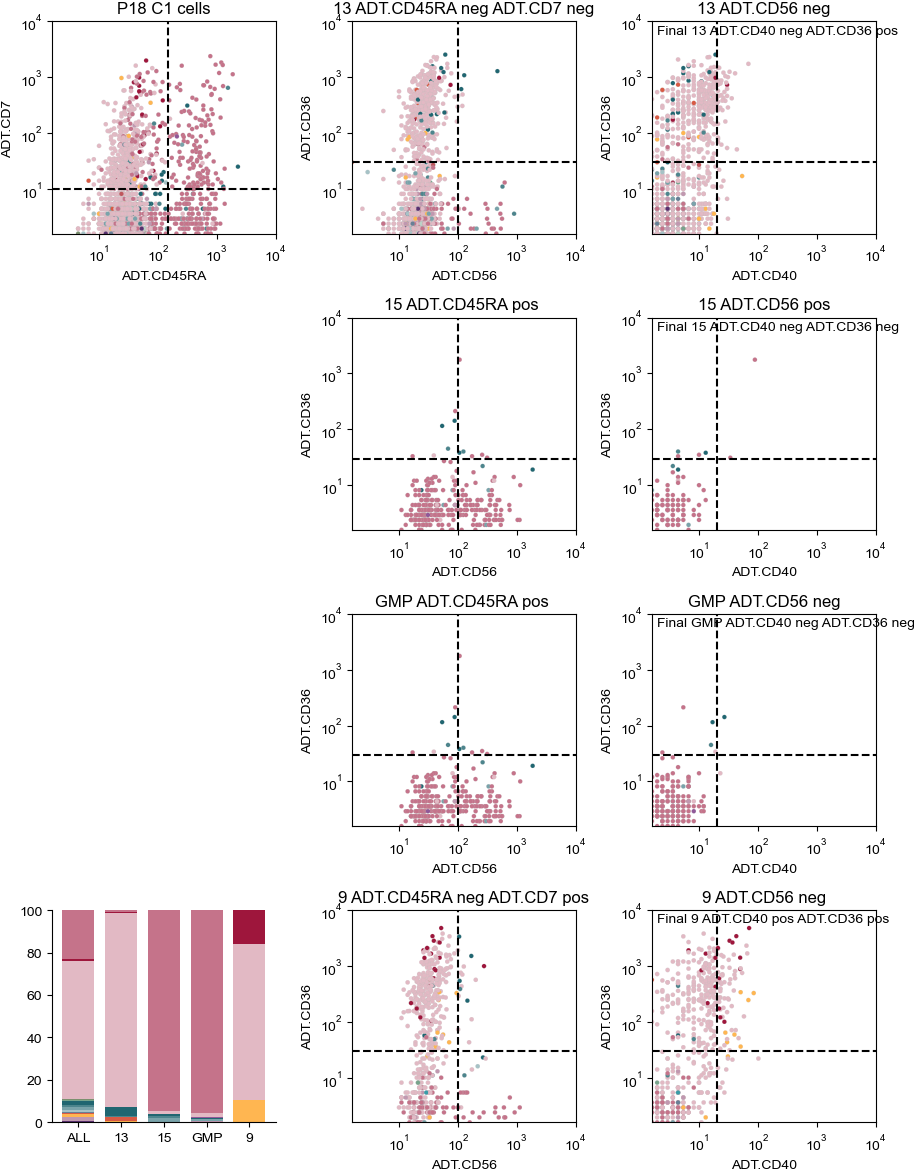

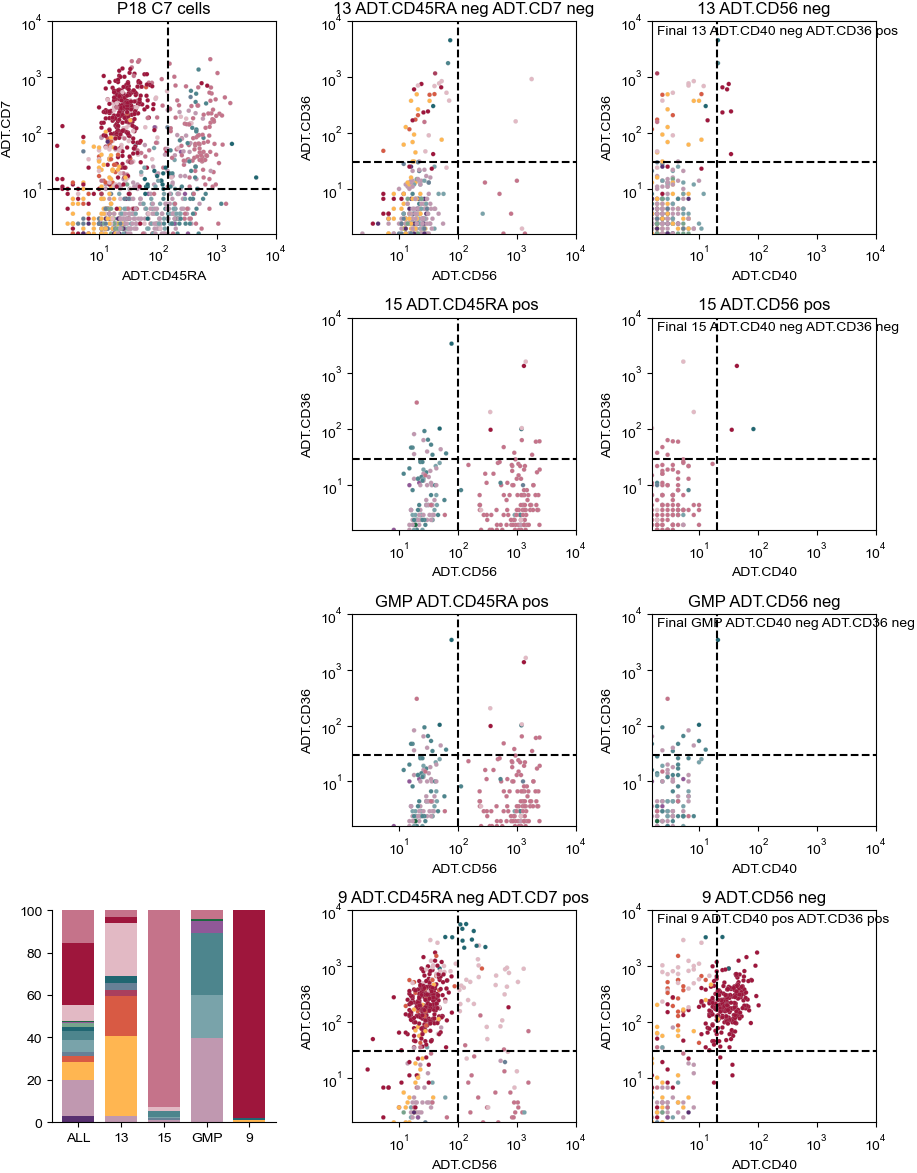

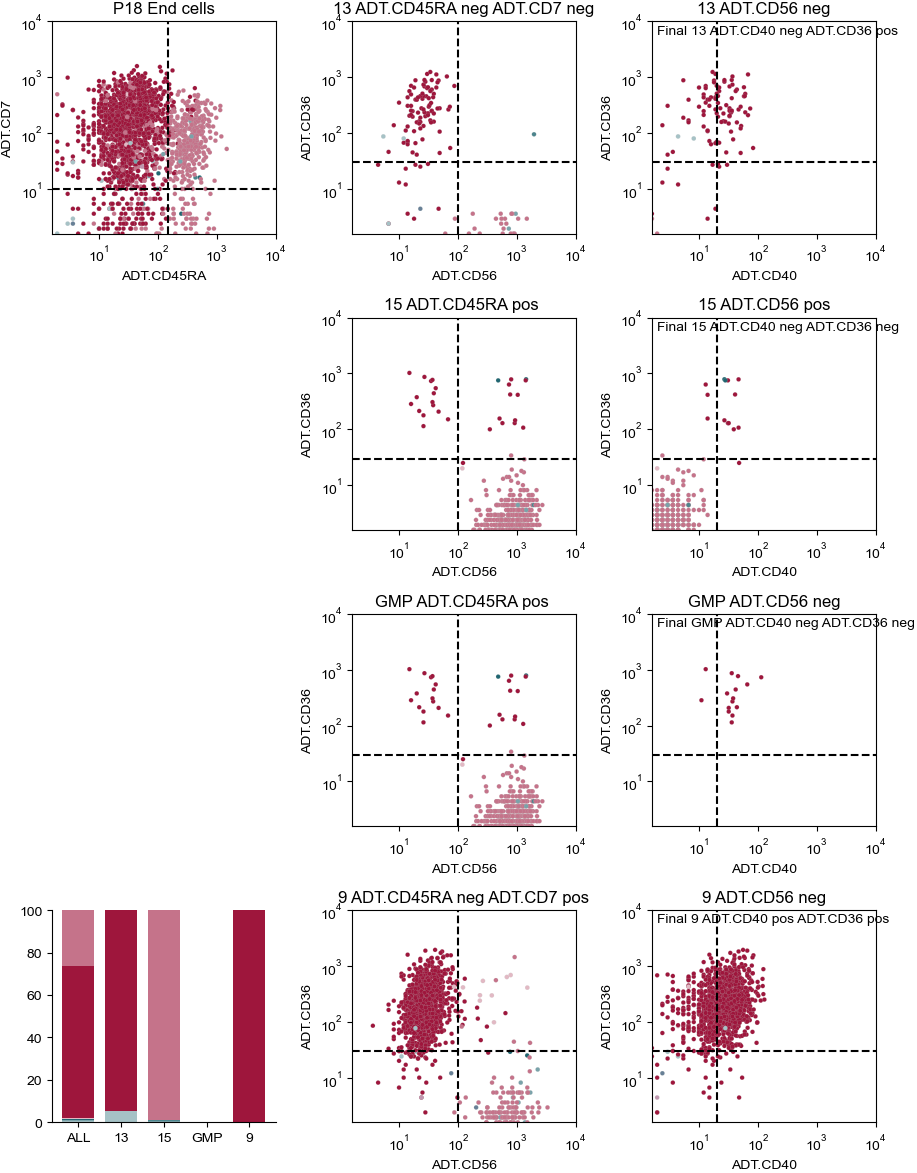

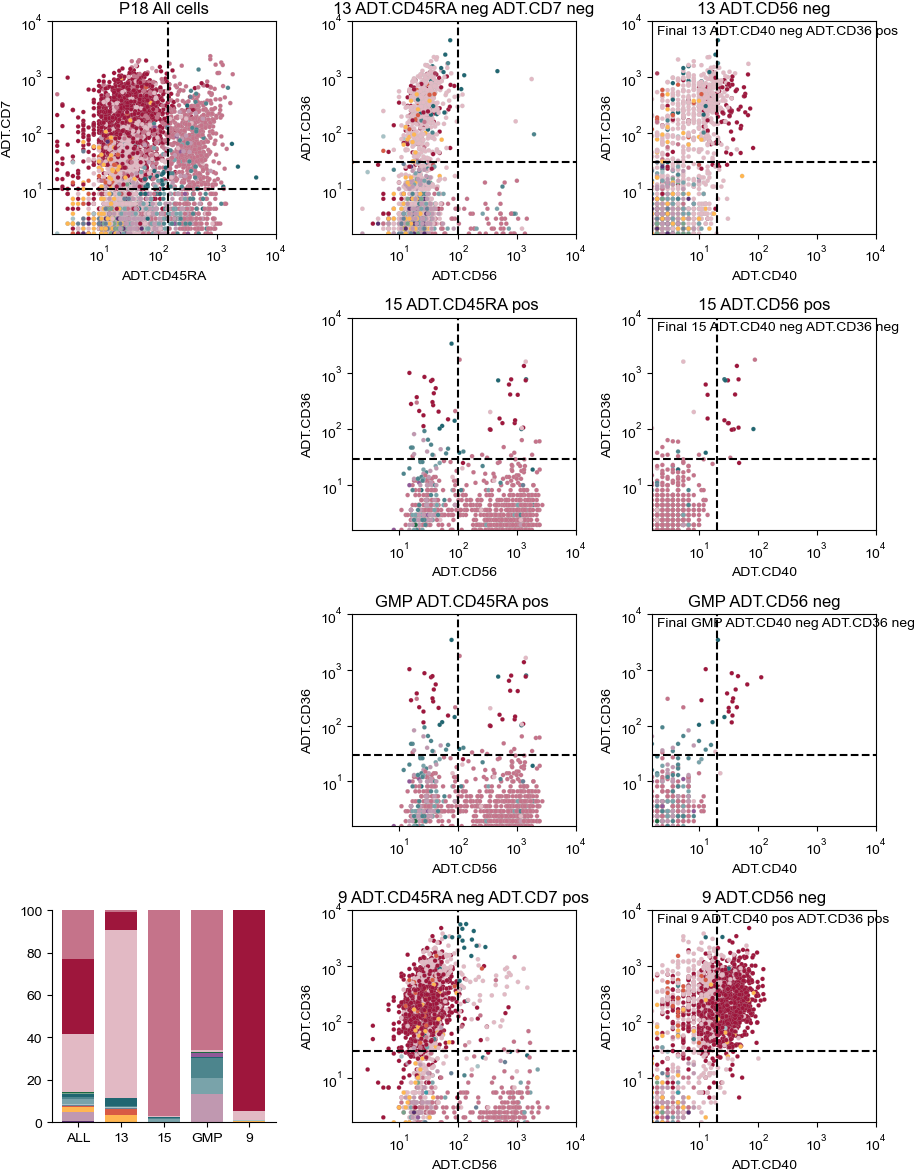

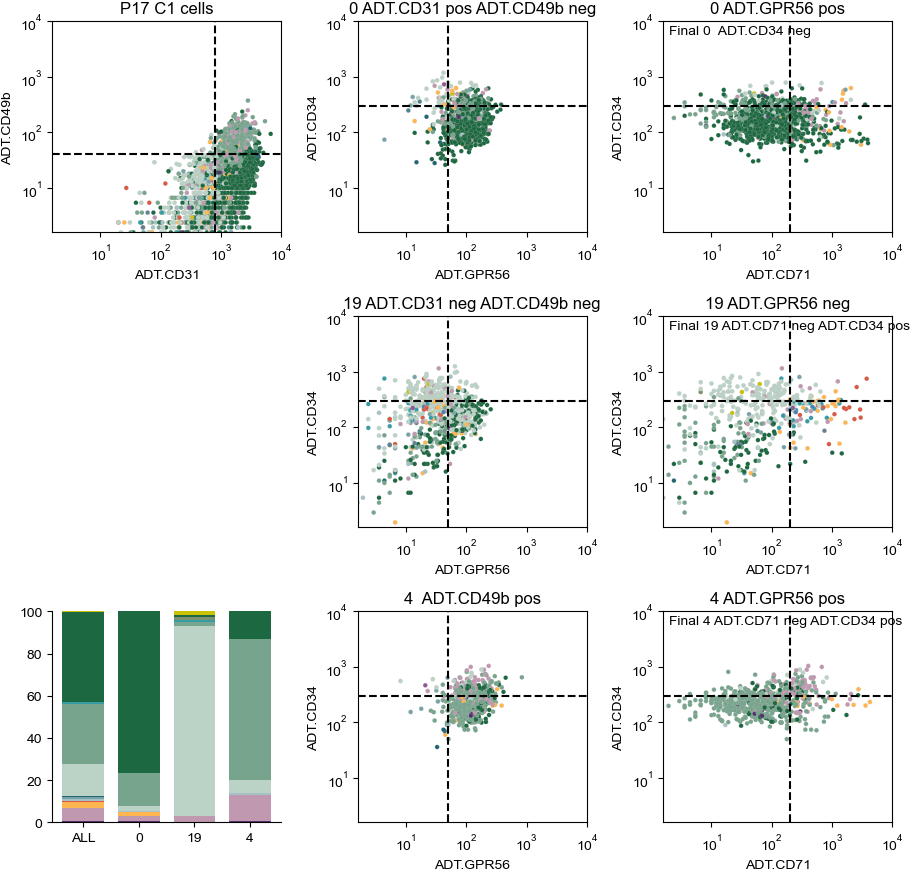

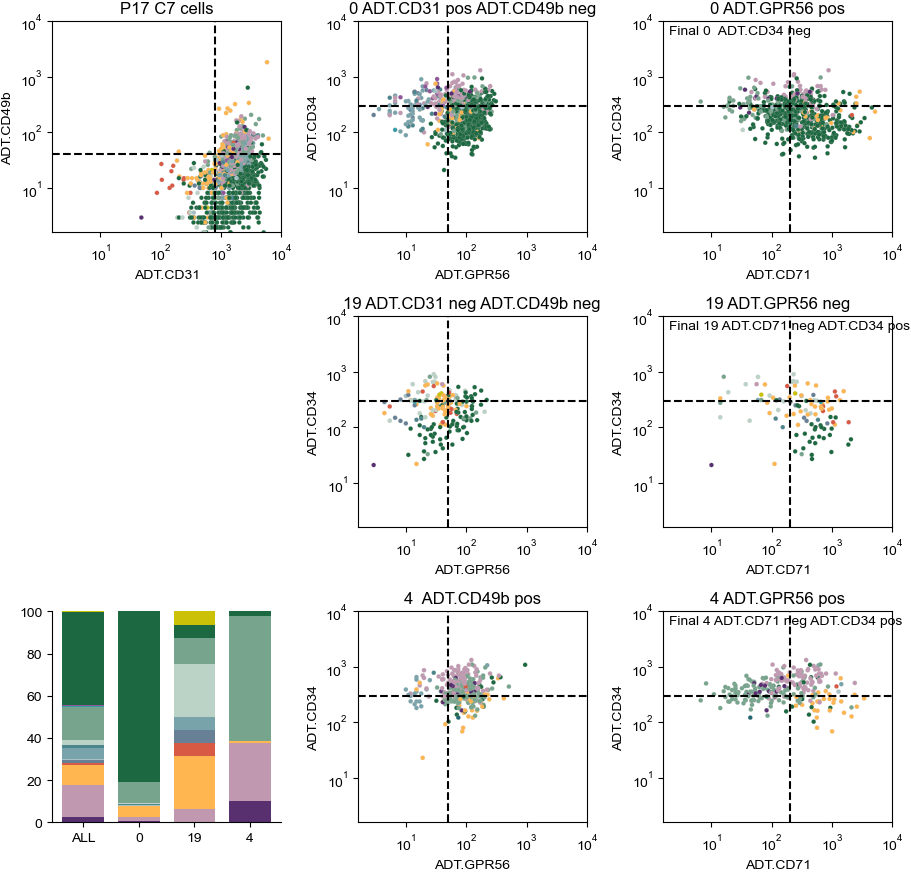

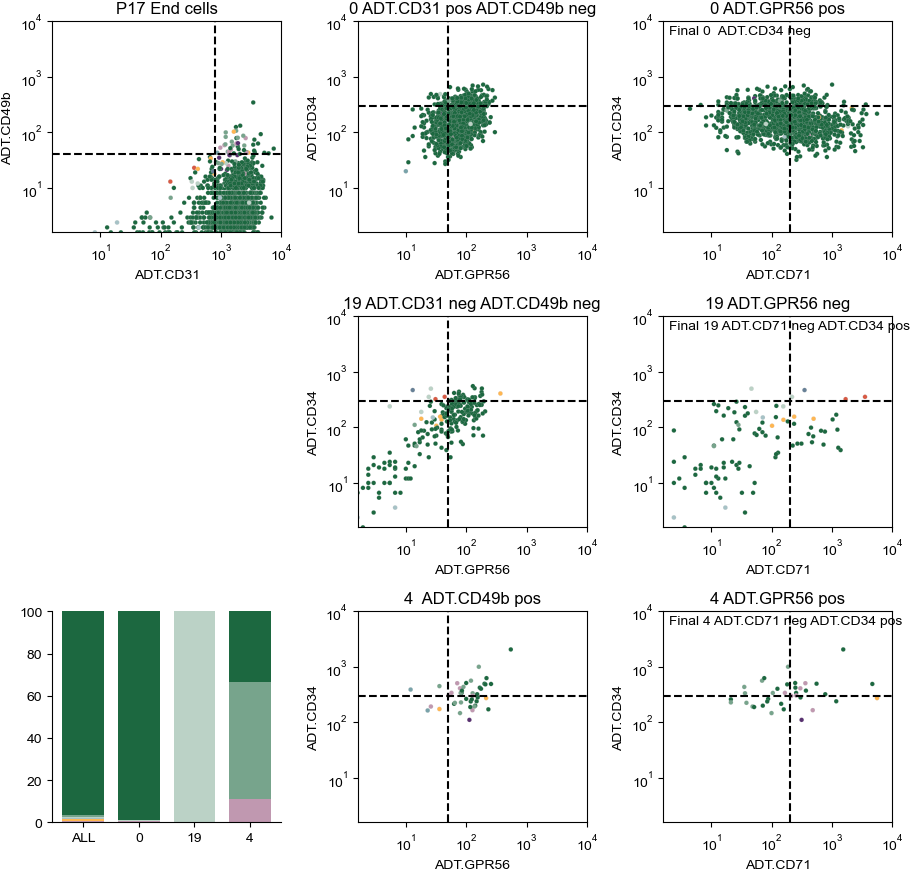

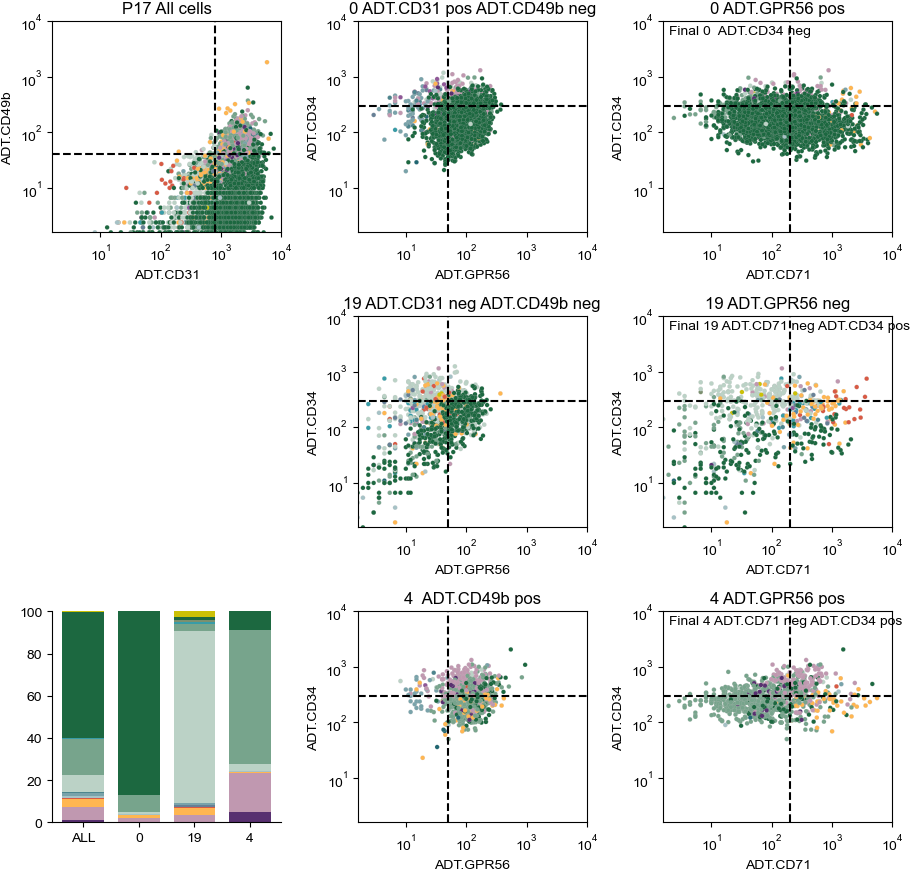

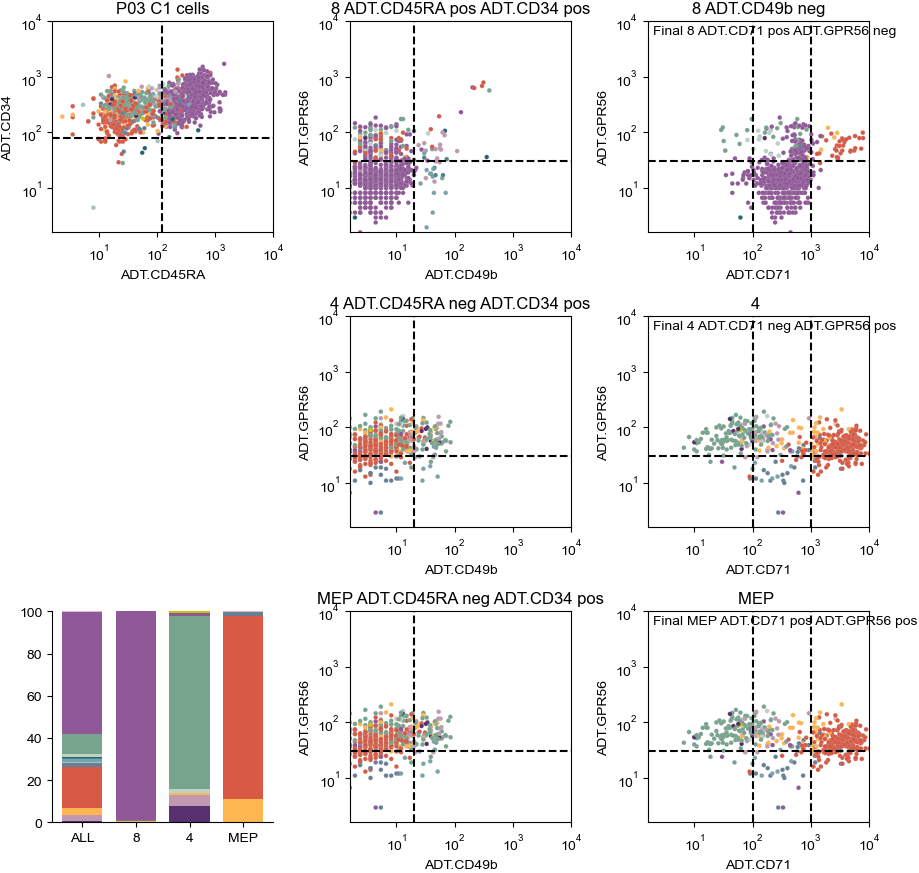

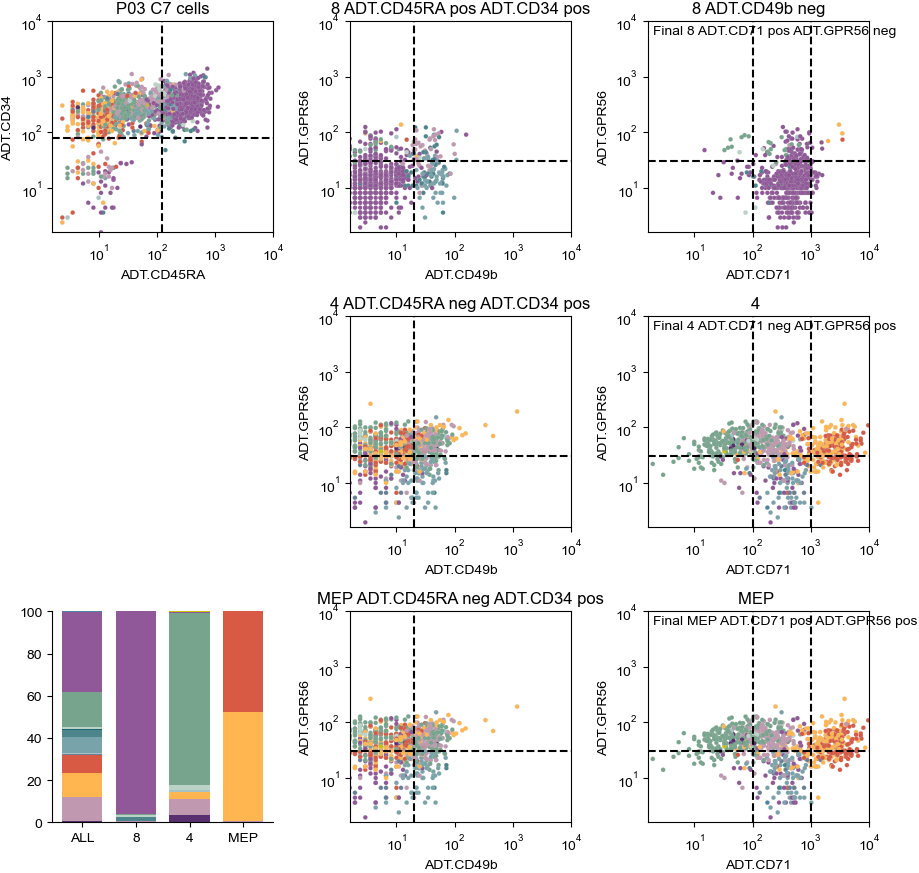

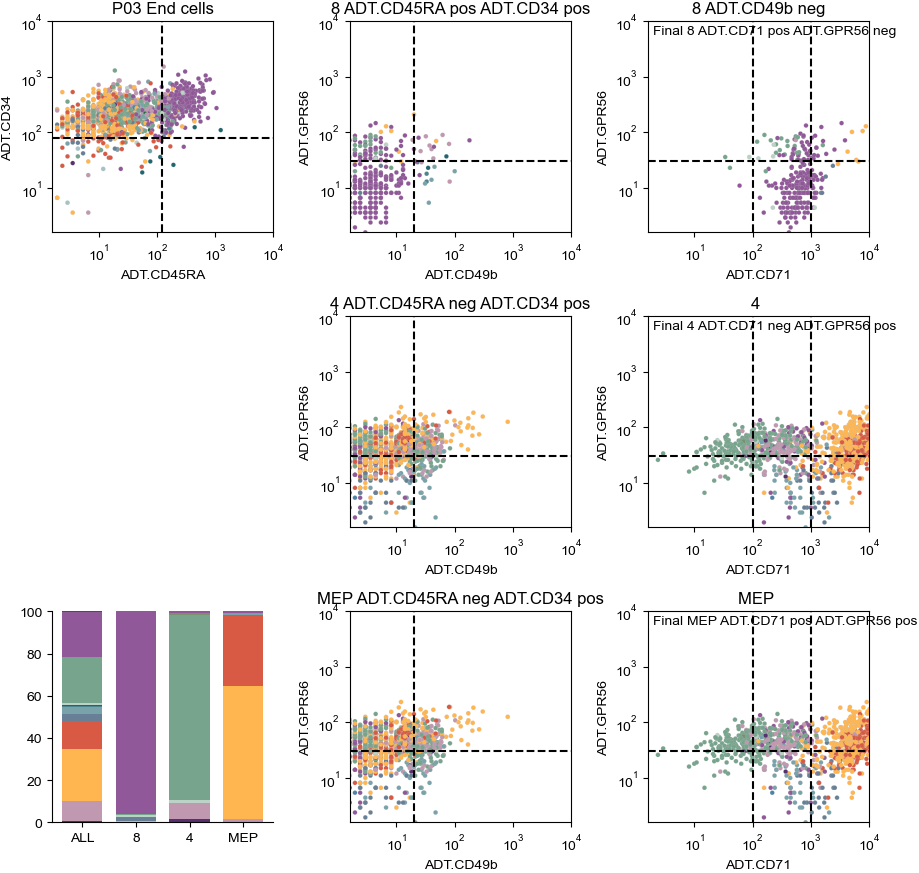

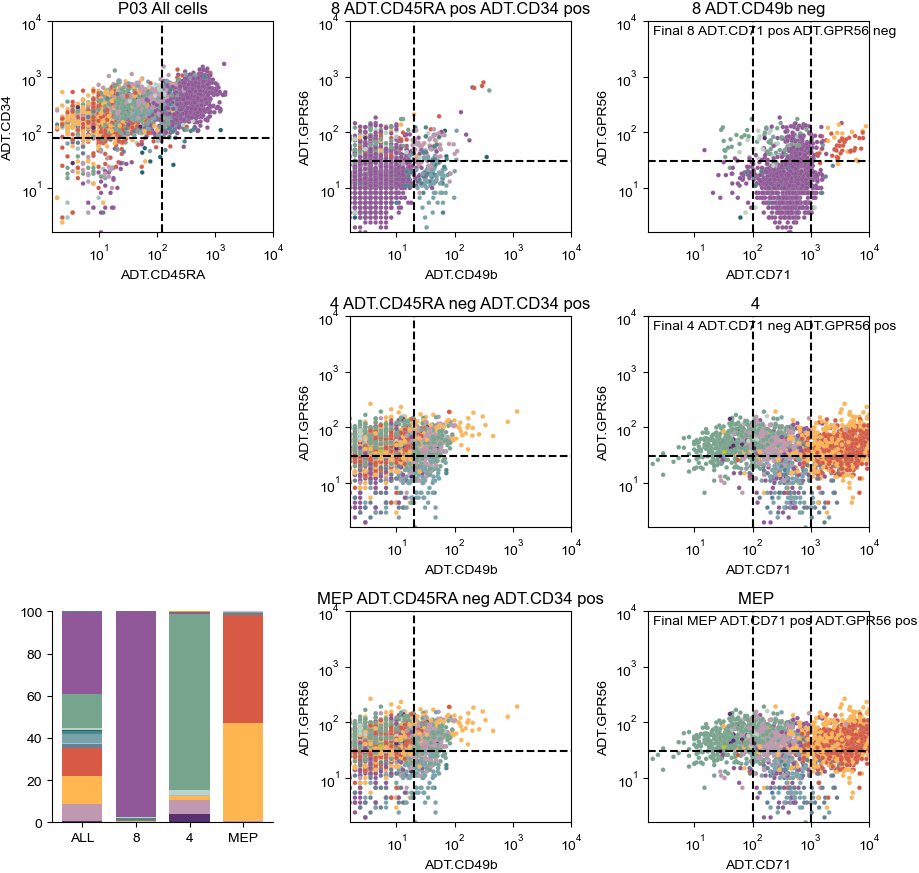

In [23]:
lw = 0.1
ec = 'silver'

#-----Set up timepoint filtering-----
tp_dict = {'C1':['C1'],
           'C7':['C7'],
           'End':['End'],
           'All':['C1', 'C7', 'End']}

for s in sheets:
#for s in ['P03']:

    for tpl in ['C1', 'C7', 'End', 'All']:
        
        tp = tp_dict[tpl]

        #----generate the antibodies to plot
        x1 = plot_order[s][0]  #Generate the antibodies to plot
        y1 = plot_order[s][1]
        x2 = plot_order[s][2]
        y2 = plot_order[s][3]
        x3 = plot_order[s][4]
        y3 = plot_order[s][5]
    
        all_ab = list(set(plot_order[s].values()))
        all_ab.append('leiden')
        all_ab.append('timepoint')
    
    
        #----filter the plotting data
        data = df_all.loc[(df_all['patient_alias']==s) & (df_all['timepoint'].isin(tp))][all_ab].copy()
        
        
        #----make the plotting space
        nrows = len(plot_pops[s])
        fig, ax = plt.subplots(nrows, 3, figsize = (9.5, 3*nrows))
        ax=ax.flatten()
        for a in ax:
            a.set_rasterization_zorder(1) #rasterize scatter plots ofr easier handling in illustrator
    
        #----First plot with everything
        axes=ax[0]
        sns.scatterplot(x=x1, y=y1, data = data, hue = 'leiden', palette = colors_dict, ax = axes, s=10, lw = lw, edgecolor=ec, zorder=0)
        axes.set_xlabel(x1)
        axes.set_ylabel(y1)
        axes.set_xscale("symlog", linthresh=10, linscale=0.8)
        axes.set_yscale("symlog", linthresh=10, linscale=0.8)
        axes.set_xlim(1, 10000)
        axes.set_ylim(1, 10000)
        axes.axvline(x=gate_dict[s][x1], color = 'k', linestyle = '--')
        axes.axhline(y=gate_dict[s][y1], color = 'k', linestyle = '--')
        axes.get_legend().remove()
        axes.set_title(f'{s} {tpl} cells')
    
        #----Second plot using gated populations from first plot
        for i, p in enumerate(plot_pops[s]):
            axno = 1+3*i
            axes=ax[axno]
            #----turn off left hand plot for all but first and last rows
            if (i>0) & (i<(nrows-1)):
                ax[axno-1].set_axis_off()
    
            #----Use gates to select population of interest
            x_type = bools[s][p][x1]
            x_cut = gate_dict[s][x1]
            y_type = bools[s][p][y1]
            y_cut = gate_dict[s][y1]
            x_mask = make_mask(data[x1], x_type, x_cut)
            y_mask = make_mask(data[y1], y_type, y_cut)
            gate1 = x_mask & y_mask
    
            #Make text labels
            x_desc = describe(x1, x_type)
            y_desc = describe(y1, y_type)
            
            data2 = data[gate1]
            sns.scatterplot(x=x2, y=y2, data = data2, hue = 'leiden', palette = colors_dict, ax = axes, s=10, lw = lw, edgecolor=ec, zorder=0)
            #axes.text(2,6000,f'{s} {p} {x_desc} {y_desc}')
            axes.set_xlabel(x2)
            axes.set_ylabel(y2)
            axes.set_xscale("symlog", linthresh=10, linscale=0.8)
            axes.set_yscale("symlog", linthresh=10, linscale=0.8)
            axes.set_xlim(1, 10000)
            axes.set_ylim(1, 10000)
            axes.axvline(x=gate_dict[s][x2], color = 'k', linestyle = '--')
            axes.axhline(y=gate_dict[s][y2], color = 'k', linestyle = '--')
            axes.get_legend().remove()
            axes.set_title(f'{p} {x_desc} {y_desc}')
    
            #----Third plot using gated populations from first plot
            axno = 2+3*i
            axes=ax[axno]
    
            #----Use gates to select population of interest
            x_type = bools[s][p][x2]
            x_cut = gate_dict[s][x2]
            y_type = bools[s][p][y2]
            y_cut = gate_dict[s][y2]
            x_mask = make_mask(data[x2], x_type, x_cut)
            #y_mask = make_mask(data[y2], y_type, y_cut)
            gate2 = gate1 & x_mask #& y_mask
    
            #Make text labels
            x_desc = describe(x2, x_type)
            y_desc = describe(y2, y_type)
            
            data3 = data[gate2]
            sns.scatterplot(x=x3, y=y3, data = data3, hue = 'leiden', palette = colors_dict, ax = axes, s=10, lw = lw, edgecolor=ec, zorder=0)
            #axes.text(2,6000,f'{s} {p} {x_desc} {y_desc}')
            axes.set_xlabel(x3)
            axes.set_ylabel(y3)
            axes.set_xscale("symlog", linthresh=10, linscale=0.8)
            axes.set_yscale("symlog", linthresh=10, linscale=0.8)
            axes.set_xlim(1, 10000)
            axes.set_ylim(1, 10000)
            axes.axvline(x=gate_dict[s][x3], color = 'k', linestyle = '--')
            axes.axhline(y=gate_dict[s][y3], color = 'k', linestyle = '--')
            if (x3 == 'ADT.CD71') & (s == 'P03'):
                axes.axvline(x=cd71hi, color = 'k', linestyle = '--')
            axes.get_legend().remove()
            #axes.set_title(f'{s} {p} {x_desc} {y_desc}')
            axes.set_title(f'{p} {x_desc}') #Remove y value as that gate not added until final plot
    
            #----Use gates to select final population
            x_type = bools[s][p][x3]
            x_cut = gate_dict[s][x3]
            y_type = bools[s][p][y3]
            y_cut = gate_dict[s][y3]
    
            if (s == 'P03') & (x3 == 'ADT.CD71'):
                x_low, x_mid, x_high = make_cd71_masks(data[x3], x_cut, cd71hi)
                x_mask = make_mask(data[x3], x_type, x_cut)
            else:
                x_mask = make_mask(data[x3], x_type, x_cut)
            y_mask = make_mask(data[y3], y_type, y_cut)
    
            if (s == 'P03') & (x3 == 'ADT.CD71') & (p == 'MEP'):
                gate3 = gate1 & gate2 & x_high & y_mask
            elif (s == 'P03') & (x3 == 'ADT.CD71') & (p == '8'):
                gate3 = gate1 & gate2 & x_mid & y_mask
            elif (s == 'P03') & (x3 == 'ADT.CD71') & (p == '4'):
                #gate3 = gate1 & gate2 & x_low & y_mask #not performing as expected
                gate3 = gate1 & gate2 & x_mask & y_mask
            else:
               gate3 = gate1 & gate2 & x_mask & y_mask
    
            #Make text labels
            x_desc = describe(x3, x_type)
            y_desc = describe(y3, y_type)
            axes.text(2,6000,f'Final {p} {x_desc} {y_desc}')
            
            data4 = data[gate3]
    
            #----Purity plots
            bar_width = 0.75
            lclusters_int = [2,6, 1,11,24,17,21,5,16,12,19, 4, 14, 3, 23, 8, 20, 22, 25, 0, 13, 9, 15, 7, 18, 10]
            axes = ax[(nrows*3)-3]
            bottom = 0
            for category in lclusters_int:
                height = pd.Series.to_dict(data4['leiden'].value_counts(normalize=True) * 100).get(category, 0)
                color = colors_dict[category]
                axes.bar(i+1,height,bar_width,bottom = bottom, color = color)
                       
                bottom += height #update bottom value for next plot
    
        axes = ax[(nrows*3)-3]
        bottom = 0
        for category in lclusters_int:
            height = pd.Series.to_dict(data['leiden'].value_counts(normalize=True) * 100).get(category, 0)
            color = colors_dict[category]
            axes.bar(0,height,bar_width,bottom = bottom, color = color)
                   
            bottom += height #update bottom value for next plot
    
        xlabs = ['ALL']
        for j in plot_pops[s]:
            xlabs.append(j)
        
        axes.set_xticks([k for k in range(nrows+1)])  
        axes.set_xticklabels(xlabs)
        axes.spines['top'].set_visible(False) 
        axes.spines['right'].set_visible(False)
    
        fig.tight_layout()

        #fig.savefig(f'../Figures/4_{s}_{tpl}_citeflow_v2_GEO.pdf',bbox_inches='tight', format='pdf', dpi = 600) #For figures